# Day 4 — Mutual Fund Performance Analytics

## Objectives

This notebook evaluates mutual fund performance using:

- Daily returns
- Annualized returns
- CAGR
- Sharpe ratio
- Sortino ratio
- Alpha and Beta versus Nifty 100
- Maximum drawdown
- Fund scorecard (0–100)
- Top 5 funds versus Nifty 50 and Nifty 100
- Tracking error

**Risk-free rate:** 6.5% annualized

**Benchmark:** Nifty 100

In [17]:
# ============================================================
# Day 4 — Setup and Data Loading
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project directories
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RAW_DIR = BASE_DIR / "data" / "raw"
REPORTS_DIR = BASE_DIR / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Load cleaned datasets
fund_master = pd.read_csv(
    PROCESSED_DIR / "fund_master_cleaned.csv"
)

nav_history = pd.read_csv(
    PROCESSED_DIR / "nav_history_cleaned.csv"
)

performance = pd.read_csv(
    PROCESSED_DIR / "scheme_performance_cleaned.csv"
)

# Convert dates
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Load benchmark data from raw dataset
benchmark_file = next(
    RAW_DIR.glob("*10_benchmark_indices.csv")
)

benchmark = pd.read_csv(benchmark_file)

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Fund master:", fund_master.shape)
print("NAV history:", nav_history.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

print("\nBenchmark indices:")
print(benchmark["index_name"].unique())

print("\nBenchmark date range:")
print(
    benchmark["date"].min().date(),
    "to",
    benchmark["date"].max().date()
)

Fund master: (40, 15)
NAV history: (64320, 3)
Performance: (40, 19)
Benchmark: (8050, 3)

Benchmark columns:
['date', 'index_name', 'close_value']

Benchmark indices:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

Benchmark date range:
2022-01-03 to 2026-05-29


In [18]:
# ============================================================
# Step 115 — Calculate Daily NAV Returns
# ============================================================

# Sort NAV data
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).copy()

# Calculate daily percentage return for each fund
nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove the first observation for each fund
# because it has no previous NAV
daily_returns = nav_history.dropna(
    subset=["daily_return"]
).copy()

# Keep weekdays only
daily_returns = daily_returns[
    daily_returns["date"].dt.dayofweek < 5
].copy()

print("Daily return observations:", f"{len(daily_returns):,}")

print(
    "Number of funds:",
    daily_returns["amfi_code"].nunique()
)

print(
    "Date range:",
    daily_returns["date"].min().date(),
    "to",
    daily_returns["date"].max().date()
)

print("\nDaily return summary:")
print(
    daily_returns["daily_return"]
    .describe()
    .round(6)
)

print("\nMissing daily returns:")
print(
    daily_returns["daily_return"].isna().sum()
)

print("\nInfinite daily returns:")
print(
    np.isinf(daily_returns["daily_return"]).sum()
)

Daily return observations: 45,960
Number of funds: 40
Date range: 2022-01-04 to 2026-05-29

Daily return summary:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Missing daily returns:
0

Infinite daily returns:
0


In [19]:
# ============================================================
# Step 116 — Annualized Return for All 40 Funds
# ============================================================

annualized_returns = (
    daily_returns
    .groupby("amfi_code")["daily_return"]
    .agg(
        cumulative_growth=lambda x: (1 + x).prod(),
        n_observations="count"
    )
    .reset_index()
)

# Annualized return using 252 trading days
annualized_returns["annualized_return"] = (
    annualized_returns["cumulative_growth"]
    ** (252 / annualized_returns["n_observations"])
    - 1
)

# Add fund names
annualized_returns["scheme_name"] = (
    annualized_returns["amfi_code"]
    .map(
        fund_master.set_index("amfi_code")["scheme_name"]
    )
)

# Convert to percentage
annualized_returns["annualized_return_pct"] = (
    annualized_returns["annualized_return"] * 100
)

# Sort highest to lowest
annualized_returns = annualized_returns.sort_values(
    "annualized_return",
    ascending=False
).reset_index(drop=True)

print("Annualized returns — all 40 funds:")
print(
    annualized_returns[
        [
            "amfi_code",
            "scheme_name",
            "n_observations",
            "annualized_return_pct"
        ]
    ].round(2).to_string(index=False)
)

print("\nTop 5 funds by annualized return:")
print(
    annualized_returns[
        ["scheme_name", "annualized_return_pct"]
    ]
    .head(5)
    .round(2)
    .to_string(index=False)
)

Annualized returns — all 40 funds:
 amfi_code                                           scheme_name  n_observations  annualized_return_pct
    120505              ICICI Pru Midcap Fund - Regular - Growth            1149                  31.51
    119598            SBI Small Cap Fund - Regular Plan - Growth            1149                  31.13
    149324                 DSP Small Cap Fund - Regular - Growth            1149                  31.00
    148569         Mirae Asset Tax Saver Fund - Regular - Growth            1149                  30.67
    148567         Mirae Asset Large Cap Fund - Regular - Growth            1149                  29.74
    120843                Kotak Flexicap Fund - Regular - Growth            1149                  29.68
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth            1149                  28.93
    149323                    DSP Midcap Fund - Regular - Growth            1149                  28.41
    119094                   

In [20]:
# ============================================================
# Step 117 — CAGR: 1-Year, 3-Year and 5-Year
# ============================================================

# Latest available NAV date
latest_date = nav_history["date"].max()

print("Latest NAV date:", latest_date.date())

# CAGR periods
periods = {
    "1Y": 1,
    "3Y": 3,
    "5Y": 5
}

cagr_results = []

for code, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    latest_row = group.iloc[-1]
    latest_nav = latest_row["nav"]
    latest_nav_date = latest_row["date"]

    result = {
        "amfi_code": code,
        "latest_nav_date": latest_nav_date,
        "latest_nav": latest_nav
    }

    for label, years in periods.items():

        target_date = latest_nav_date - pd.DateOffset(years=years)

        # Find NAV closest to target date
        historical = group[
            group["date"] <= target_date
        ]

        if len(historical) == 0:
            result[f"cagr_{label}"] = np.nan
            continue

        start_row = historical.iloc[-1]

        start_nav = start_row["nav"]
        start_date = start_row["date"]

        # Require the observation to be reasonably close
        # to the target date.
        days_difference = (
            target_date - start_date
        ).days

        if days_difference > 10:
            result[f"cagr_{label}"] = np.nan
        else:
            actual_years = (
                latest_nav_date - start_date
            ).days / 365.25

            cagr = (
                (latest_nav / start_nav)
                ** (1 / actual_years)
                - 1
            )

            result[f"cagr_{label}"] = cagr * 100

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

# Add scheme names
cagr_df["scheme_name"] = (
    cagr_df["amfi_code"]
    .map(
        fund_master.set_index("amfi_code")["scheme_name"]
    )
)

# Arrange columns
cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "cagr_1Y",
        "cagr_3Y",
        "cagr_5Y"
    ]
].sort_values(
    "cagr_3Y",
    ascending=False
)

print("\nCAGR results:")
print(
    cagr_df.round(2).to_string(index=False)
)

print("\nAvailable CAGR observations:")
print(
    cagr_df[
        ["cagr_1Y", "cagr_3Y", "cagr_5Y"]
    ].notna().sum()
)

Latest NAV date: 2026-05-29

CAGR results:
 amfi_code                                           scheme_name  cagr_1Y  cagr_3Y  cagr_5Y
    119094                   Axis Midcap Fund - Regular - Growth    22.28    35.10      NaN
    148567         Mirae Asset Large Cap Fund - Regular - Growth    20.38    33.99      NaN
    120504             ICICI Pru Bluechip Fund - Direct - Growth    13.07    32.48      NaN
    100033    HDFC Mid-Cap Opportunities Fund - Regular - Growth    53.28    32.43      NaN
    120505              ICICI Pru Midcap Fund - Regular - Growth    29.63    31.77      NaN
    119551             SBI Bluechip Fund - Regular Plan - Growth    60.49    30.45      NaN
    120843                Kotak Flexicap Fund - Regular - Growth    26.68    29.58      NaN
    148569         Mirae Asset Tax Saver Fund - Regular - Growth    39.78    29.17      NaN
    101206         ABSL Frontline Equity Fund - Regular - Growth    47.96    28.96      NaN
    149324                 DSP Small 

In [21]:
# ============================================================
# Step 118 — Sharpe Ratio
# ============================================================

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

# Calculate annualized volatility
volatility = (
    daily_returns
    .groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(TRADING_DAYS)
)

volatility = volatility.rename("volatility_ann")

# Merge annualized return with volatility
sharpe_df = annualized_returns[
    ["amfi_code", "scheme_name", "annualized_return"]
].copy()

sharpe_df = sharpe_df.merge(
    volatility,
    on="amfi_code",
    how="left"
)

# Sharpe ratio
sharpe_df["sharpe_ratio"] = (
    (sharpe_df["annualized_return"] - RISK_FREE_RATE)
    / sharpe_df["volatility_ann"]
)

# Convert volatility to percentage
sharpe_df["volatility_ann_pct"] = (
    sharpe_df["volatility_ann"] * 100
)

# Sort by Sharpe
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).reset_index(drop=True)

print("Sharpe Ratio — all 40 funds:")
print(
    sharpe_df[
        [
            "scheme_name",
            "annualized_return",
            "volatility_ann_pct",
            "sharpe_ratio"
        ]
    ].round(3).to_string(index=False)
)

print("\nTop 5 funds by Sharpe Ratio:")
print(
    sharpe_df[
        ["scheme_name", "sharpe_ratio"]
    ]
    .head(5)
    .round(3)
    .to_string(index=False)
)

print("\nRisk-free rate:", "6.5%")
print("Annualization factor:", "sqrt(252)")

Sharpe Ratio — all 40 funds:
                                          scheme_name  annualized_return  volatility_ann_pct  sharpe_ratio
        Mirae Asset Large Cap Fund - Regular - Growth              0.297              14.194         1.637
               Kotak Flexicap Fund - Regular - Growth              0.297              15.887         1.459
        Mirae Asset Tax Saver Fund - Regular - Growth              0.307              17.674         1.368
            SBI Bluechip Fund - Regular Plan - Growth              0.248              13.741         1.331
             ICICI Pru Midcap Fund - Regular - Growth              0.315              19.291         1.297
                   DSP Midcap Fund - Regular - Growth              0.284              17.746         1.235
   HDFC Mid-Cap Opportunities Fund - Regular - Growth              0.289              18.937         1.184
       Nippon India Large Cap Fund - Regular - Growth              0.231              14.148         1.174
        

In [22]:
# ============================================================
# Step 119 — Sortino Ratio
# ============================================================

# Downside returns: only negative daily returns
downside_returns = daily_returns[
    daily_returns["daily_return"] < 0
].copy()

# Downside deviation
downside_deviation = (
    downside_returns
    .groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(TRADING_DAYS)
)

downside_deviation = downside_deviation.rename(
    "downside_deviation_ann"
)

# Start with annualized return
sortino_df = annualized_returns[
    ["amfi_code", "scheme_name", "annualized_return"]
].copy()

sortino_df = sortino_df.merge(
    downside_deviation,
    on="amfi_code",
    how="left"
)

# Sortino ratio
sortino_df["sortino_ratio"] = (
    (sortino_df["annualized_return"] - RISK_FREE_RATE)
    / sortino_df["downside_deviation_ann"]
)

# Sort highest to lowest
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).reset_index(drop=True)

print("Sortino Ratio — all 40 funds:")
print(
    sortino_df[
        [
            "scheme_name",
            "annualized_return",
            "downside_deviation_ann",
            "sortino_ratio"
        ]
    ].round(3).to_string(index=False)
)

print("\nTop 5 funds by Sortino Ratio:")
print(
    sortino_df[
        ["scheme_name", "sortino_ratio"]
    ]
    .head(5)
    .round(3)
    .to_string(index=False)
)

print("\nRisk-free rate:", "6.5%")

Sortino Ratio — all 40 funds:
                                          scheme_name  annualized_return  downside_deviation_ann  sortino_ratio
        Mirae Asset Large Cap Fund - Regular - Growth              0.297                   0.086          2.697
               Kotak Flexicap Fund - Regular - Growth              0.297                   0.088          2.640
        Mirae Asset Tax Saver Fund - Regular - Growth              0.307                   0.102          2.378
            SBI Bluechip Fund - Regular Plan - Growth              0.248                   0.078          2.359
             ICICI Pru Midcap Fund - Regular - Growth              0.315                   0.112          2.230
                   DSP Midcap Fund - Regular - Growth              0.284                   0.107          2.045
             ICICI Pru Liquid Fund - Regular - Growth              0.070                   0.002          2.042
       Nippon India Large Cap Fund - Regular - Growth              0.231  

In [23]:
# ============================================================
# Step 120 — Maximum Drawdown
# ============================================================

max_dd_results = []

for code, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    running_peak = group["nav"].cummax()

    # Drawdown from previous peak
    drawdown = (
        group["nav"] / running_peak
    ) - 1

    max_drawdown = drawdown.min()

    max_dd_results.append({
        "amfi_code": code,
        "max_drawdown": max_drawdown
    })

max_dd_df = pd.DataFrame(max_dd_results)

# Add scheme names
max_dd_df["scheme_name"] = (
    max_dd_df["amfi_code"]
    .map(
        fund_master.set_index("amfi_code")["scheme_name"]
    )
)

# Percentage representation
max_dd_df["max_drawdown_pct"] = (
    max_dd_df["max_drawdown"] * 100
)

# Most severe drawdown first
max_dd_df = max_dd_df.sort_values(
    "max_drawdown"
).reset_index(drop=True)

print("Maximum Drawdown — all 40 funds:")
print(
    max_dd_df[
        ["scheme_name", "max_drawdown_pct"]
    ]
    .round(2)
    .to_string(index=False)
)

print("\n5 funds with the most severe drawdowns:")
print(
    max_dd_df[
        ["scheme_name", "max_drawdown_pct"]
    ]
    .head(5)
    .round(2)
    .to_string(index=False)
)

print("\n5 funds with the lowest drawdowns:")
print(
    max_dd_df[
        ["scheme_name", "max_drawdown_pct"]
    ]
    .tail(5)
    .sort_values("max_drawdown_pct", ascending=False)
    .round(2)
    .to_string(index=False)
)

Maximum Drawdown — all 40 funds:
                                          scheme_name  max_drawdown_pct
            SBI Small Cap Fund - Direct Plan - Growth            -52.57
               Axis Small Cap Fund - Regular - Growth            -51.68
               ABSL Small Cap Fund - Regular - Growth            -35.45
                DSP Small Cap Fund - Regular - Growth            -31.17
           SBI Small Cap Fund - Regular Plan - Growth            -28.71
                  UTI Mid Cap Fund - Regular - Growth            -28.00
            HDFC Top 100 Fund - Regular Plan - Growth            -24.73
        Kotak Emerging Equity Fund - Regular - Growth            -24.00
       Nippon India Small Cap Fund - Regular - Growth            -23.34
                 Axis Bluechip Fund - Direct - Growth            -21.75
                UTI Flexi Cap Fund - Regular - Growth            -21.54
    HDFC Mid-Cap Opportunities Fund - Direct - Growth            -21.12
                  Axis Midcap F

In [24]:
# ============================================================
# Step 121 — Alpha & Beta vs Nifty 100
# ============================================================

from scipy.stats import linregress

# Get Nifty 100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Calculate daily Nifty 100 returns
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

alpha_beta_results = []

for code, fund_data in daily_returns.groupby("amfi_code"):

    # Merge fund and benchmark returns by date
    merged = fund_data[
        ["date", "daily_return"]
    ].merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    # Need sufficient observations for regression
    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    # Daily intercept converted to annualized alpha
    alpha = regression.intercept * TRADING_DAYS

    alpha_beta_results.append({
        "amfi_code": code,
        "beta": beta,
        "alpha": alpha,
        "r_squared": regression.rvalue ** 2,
        "observations": len(merged)
    })

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

# Add scheme names
alpha_beta_df["scheme_name"] = (
    alpha_beta_df["amfi_code"]
    .map(
        fund_master.set_index("amfi_code")["scheme_name"]
    )
)

# Alpha as percentage
alpha_beta_df["alpha_pct"] = (
    alpha_beta_df["alpha"] * 100
)

# Sort by alpha
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)

print("Alpha & Beta vs Nifty 100:")
print(
    alpha_beta_df[
        [
            "scheme_name",
            "alpha_pct",
            "beta",
            "r_squared",
            "observations"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print("\nTop 5 funds by Alpha:")
print(
    alpha_beta_df[
        ["scheme_name", "alpha_pct", "beta"]
    ]
    .head(5)
    .round(3)
    .to_string(index=False)
)

print("\nBenchmark: NIFTY100")
print(
    "Benchmark observations:",
    len(nifty100)
)

Alpha & Beta vs Nifty 100:
                                          scheme_name  alpha_pct   beta  r_squared  observations
           SBI Small Cap Fund - Regular Plan - Growth     30.337 -0.023      0.000          1149
                DSP Small Cap Fund - Regular - Growth     30.058  0.011      0.000          1149
             ICICI Pru Midcap Fund - Regular - Growth     29.264  0.001      0.000          1149
        Mirae Asset Tax Saver Fund - Regular - Growth     28.270  0.018      0.000          1149
               Kotak Flexicap Fund - Regular - Growth     27.330 -0.023      0.000          1149
   HDFC Mid-Cap Opportunities Fund - Regular - Growth     27.195  0.005      0.000          1149
        Mirae Asset Large Cap Fund - Regular - Growth     26.984  0.024      0.000          1149
                   DSP Midcap Fund - Regular - Growth     26.599 -0.003      0.000          1149
                  Axis Midcap Fund - Regular - Growth     26.077 -0.066      0.002          1149
   

In [25]:
# ============================================================
# Step 122 — Alpha/Beta Diagnostic
# ============================================================

# Show Nifty 100 daily return statistics
print("NIFTY 100 daily return summary:")
print(
    nifty100["benchmark_return"]
    .describe()
    .round(6)
)

# Compare one representative equity fund with Nifty 100
test_code = "120505"  # ICICI Pru Midcap

test_fund = daily_returns[
    daily_returns["amfi_code"].astype(str) == test_code
][["date", "daily_return"]].copy()

test_merged = test_fund.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

print("\nTest fund:")
print(
    fund_master[
        fund_master["amfi_code"].astype(str) == test_code
    ]["scheme_name"].to_string(index=False)
)

print("\nMerged observations:", len(test_merged))

print("\nFund daily return summary:")
print(
    test_merged["daily_return"]
    .describe()
    .round(6)
)

print("\nNIFTY 100 return summary:")
print(
    test_merged["benchmark_return"]
    .describe()
    .round(6)
)

print("\nCorrelation between fund and NIFTY 100:")
print(
    test_merged[
        ["daily_return", "benchmark_return"]
    ]
    .corr()
    .round(4)
)

NIFTY 100 daily return summary:
count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

Test fund:
ICICI Pru Midcap Fund - Regular - Growth

Merged observations: 1149

Fund daily return summary:
count    1149.000000
mean        0.001161
std         0.012152
min        -0.038418
25%        -0.007237
50%         0.000955
75%         0.009359
max         0.040812
Name: daily_return, dtype: float64

NIFTY 100 return summary:
count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

Correlation between fund and NIFTY 100:
                  daily_return  benchmark_return
daily_return            1.0000            0.0004
benchmark_return        0.0004            1.0000


In [26]:
# ============================================================
# Step 123 — Fund Scorecard (0–100)
# ============================================================

# Start with 3-year CAGR
scorecard = cagr_df[
    ["amfi_code", "scheme_name", "cagr_3Y"]
].copy()

# Add Sharpe
scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code",
    how="left"
)

# Add Alpha
scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code",
    how="left"
)

# Add maximum drawdown
scorecard = scorecard.merge(
    max_dd_df[
        ["amfi_code", "max_drawdown"]
    ],
    on="amfi_code",
    how="left"
)

# Add expense ratio
scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

# ------------------------------------------------------------
# Convert metrics into 0–100 percentile scores
# ------------------------------------------------------------

# Higher is better
scorecard["return_score"] = (
    scorecard["cagr_3Y"]
    .rank(pct=True) * 100
)

scorecard["sharpe_score"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True) * 100
)

scorecard["alpha_score"] = (
    scorecard["alpha"]
    .rank(pct=True) * 100
)

# Lower expense ratio is better
scorecard["expense_score"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True, pct=True) * 100
)

# Less severe drawdown is better
# Example: -5% is better than -30%
scorecard["drawdown_score"] = (
    scorecard["max_drawdown"]
    .rank(pct=True) * 100
)

# ------------------------------------------------------------
# Weighted final score
# ------------------------------------------------------------

scorecard["final_score"] = (
    scorecard["return_score"] * 0.30
    + scorecard["sharpe_score"] * 0.25
    + scorecard["alpha_score"] * 0.20
    + scorecard["expense_score"] * 0.15
    + scorecard["drawdown_score"] * 0.10
)

# Rank funds
scorecard["rank"] = (
    scorecard["final_score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

scorecard = scorecard.sort_values(
    "rank"
).reset_index(drop=True)

print("Fund Scorecard — all 40 funds:")
print(
    scorecard[
        [
            "rank",
            "scheme_name",
            "cagr_3Y",
            "sharpe_ratio",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown",
            "final_score"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print("\nTop 5 funds by final score:")
print(
    scorecard[
        [
            "rank",
            "scheme_name",
            "final_score"
        ]
    ]
    .head(5)
    .round(2)
    .to_string(index=False)
)

Fund Scorecard — all 40 funds:
 rank                                           scheme_name  cagr_3Y  sharpe_ratio  alpha  expense_ratio_pct  max_drawdown  final_score
    1         Mirae Asset Large Cap Fund - Regular - Growth   33.992         1.637  0.270               1.46        -0.113       88.125
    2         Mirae Asset Tax Saver Fund - Regular - Growth   29.171         1.368  0.283               1.60        -0.164       85.688
    3                Kotak Flexicap Fund - Regular - Growth   29.575         1.459  0.273               1.45        -0.130       83.125
    4             SBI Bluechip Fund - Regular Plan - Growth   30.449         1.331  0.232               1.54        -0.150       82.312
    5         ABSL Frontline Equity Fund - Regular - Growth   28.960         1.107  0.214               1.60        -0.113       80.188
    6                    DSP Midcap Fund - Regular - Growth   26.863         1.235  0.266               1.61        -0.172       79.875
    7    HDFC Mid

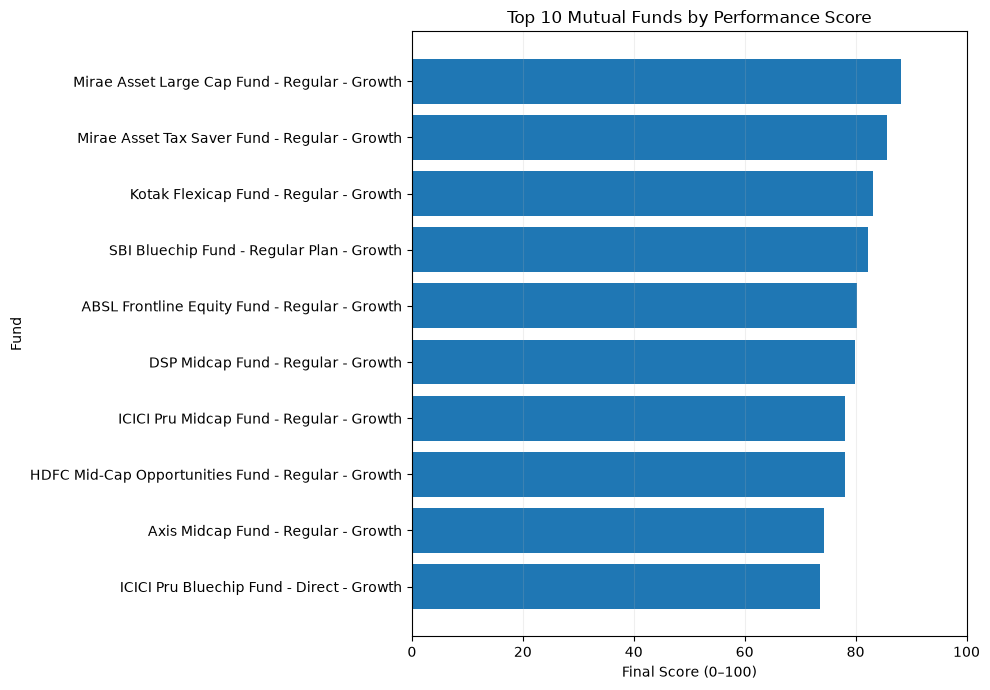

Top 10 scorecard:
 rank                                        scheme_name  final_score
    1      Mirae Asset Large Cap Fund - Regular - Growth        88.12
    2      Mirae Asset Tax Saver Fund - Regular - Growth        85.69
    3             Kotak Flexicap Fund - Regular - Growth        83.12
    4          SBI Bluechip Fund - Regular Plan - Growth        82.31
    5      ABSL Frontline Equity Fund - Regular - Growth        80.19
    6                 DSP Midcap Fund - Regular - Growth        79.88
    7 HDFC Mid-Cap Opportunities Fund - Regular - Growth        78.12
    7           ICICI Pru Midcap Fund - Regular - Growth        78.12
    9                Axis Midcap Fund - Regular - Growth        74.38
   10          ICICI Pru Bluechip Fund - Direct - Growth        73.62

Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\performance_top10_scorecard.png


In [27]:
# ============================================================
# Step 124 — Top 10 Fund Scorecard Visualization
# ============================================================

top10_scorecard = (
    scorecard
    .head(10)
    .sort_values("final_score", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top10_scorecard["scheme_name"],
    top10_scorecard["final_score"]
)

plt.title("Top 10 Mutual Funds by Performance Score")
plt.xlabel("Final Score (0–100)")
plt.ylabel("Fund")

plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()

chart_path = REPORTS_DIR / "performance_top10_scorecard.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Top 10 scorecard:")
print(
    scorecard[
        ["rank", "scheme_name", "final_score"]
    ]
    .head(10)
    .round(2)
    .to_string(index=False)
)

print("\nChart saved to:", chart_path)

In [28]:
# ============================================================
# Step 125 — Top 5 Funds vs Nifty 50 & Nifty 100
# ============================================================

# ------------------------------------------------------------
# Select Top 5 funds from the scorecard
# ------------------------------------------------------------

top5_codes = (
    scorecard
    .head(5)["amfi_code"]
    .tolist()
)

top5_names = (
    scorecard
    .head(5)["scheme_name"]
    .tolist()
)

print("Top 5 funds selected for benchmark comparison:")

for rank, name in enumerate(top5_names, start=1):
    print(f"{rank}. {name}")


# ------------------------------------------------------------
# Calculate 3-year benchmark CAGR
# ------------------------------------------------------------

benchmark_cagr_results = []

latest_benchmark_date = benchmark["date"].max()

for index_name in ["NIFTY50", "NIFTY100"]:

    index_data = benchmark[
        benchmark["index_name"] == index_name
    ].sort_values("date").copy()

    latest_row = index_data.iloc[-1]

    target_date = (
        latest_row["date"] - pd.DateOffset(years=3)
    )

    historical = index_data[
        index_data["date"] <= target_date
    ]

    start_row = historical.iloc[-1]

    start_value = start_row["close_value"]
    end_value = latest_row["close_value"]

    actual_years = (
        latest_row["date"] - start_row["date"]
    ).days / 365.25

    cagr = (
        (end_value / start_value)
        ** (1 / actual_years)
        - 1
    )

    benchmark_cagr_results.append({
        "benchmark": index_name,
        "cagr_3Y": cagr * 100
    })

benchmark_cagr = pd.DataFrame(
    benchmark_cagr_results
)

print("\nBenchmark 3-year CAGR:")
print(
    benchmark_cagr.round(2).to_string(index=False)
)


# ------------------------------------------------------------
# Calculate tracking error for Top 5 funds
# ------------------------------------------------------------

tracking_results = []

for code in top5_codes:

    fund_data = daily_returns[
        daily_returns["amfi_code"] == code
    ][
        ["date", "daily_return"]
    ].copy()

    fund_name = (
        fund_master[
            fund_master["amfi_code"] == code
        ]["scheme_name"]
        .iloc[0]
    )

    # Merge with Nifty 100
    merged = fund_data.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    ).dropna()

    # Active return
    active_return = (
        merged["daily_return"]
        - merged["benchmark_return"]
    )

    # Annualized tracking error
    tracking_error = (
        active_return.std()
        * np.sqrt(TRADING_DAYS)
        * 100
    )

    tracking_results.append({
        "amfi_code": code,
        "scheme_name": fund_name,
        "fund_cagr_3Y": scorecard[
            scorecard["amfi_code"] == code
        ]["cagr_3Y"].iloc[0],
        "nifty100_cagr_3Y": benchmark_cagr[
            benchmark_cagr["benchmark"] == "NIFTY100"
        ]["cagr_3Y"].iloc[0],
        "tracking_error_pct": tracking_error
    })

tracking_df = pd.DataFrame(
    tracking_results
)

print("\nTop 5 funds vs Nifty 100:")
print(
    tracking_df[
        [
            "scheme_name",
            "fund_cagr_3Y",
            "nifty100_cagr_3Y",
            "tracking_error_pct"
        ]
    ]
    .round(2)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Nifty 50 comparison
# ------------------------------------------------------------

nifty50_cagr = benchmark_cagr[
    benchmark_cagr["benchmark"] == "NIFTY50"
]["cagr_3Y"].iloc[0]

print("\nNifty 50 3-year CAGR:", round(nifty50_cagr, 2), "%")
print(
    "Nifty 100 3-year CAGR:",
    round(
        benchmark_cagr[
            benchmark_cagr["benchmark"] == "NIFTY100"
        ]["cagr_3Y"].iloc[0],
        2
    ),
    "%"
)

Top 5 funds selected for benchmark comparison:
1. Mirae Asset Large Cap Fund - Regular - Growth
2. Mirae Asset Tax Saver Fund - Regular - Growth
3. Kotak Flexicap Fund - Regular - Growth
4. SBI Bluechip Fund - Regular Plan - Growth
5. ABSL Frontline Equity Fund - Regular - Growth

Benchmark 3-year CAGR:
benchmark  cagr_3Y
  NIFTY50    -9.14
 NIFTY100     8.72

Top 5 funds vs Nifty 100:
                                  scheme_name  fund_cagr_3Y  nifty100_cagr_3Y  tracking_error_pct
Mirae Asset Large Cap Fund - Regular - Growth         33.99              8.72               18.97
Mirae Asset Tax Saver Fund - Regular - Growth         29.17              8.72               21.74
       Kotak Flexicap Fund - Regular - Growth         29.58              8.72               20.64
    SBI Bluechip Fund - Regular Plan - Growth         30.45              8.72               19.12
ABSL Frontline Equity Fund - Regular - Growth         28.96              8.72               19.27

Nifty 50 3-year CAGR: 

3-Year CAGR comparison:
                                  scheme_name  fund_cagr_3Y  NIFTY50  NIFTY100
Mirae Asset Large Cap Fund - Regular - Growth         33.99    -9.14      8.72
Mirae Asset Tax Saver Fund - Regular - Growth         29.17    -9.14      8.72
       Kotak Flexicap Fund - Regular - Growth         29.58    -9.14      8.72
    SBI Bluechip Fund - Regular Plan - Growth         30.45    -9.14      8.72
ABSL Frontline Equity Fund - Regular - Growth         28.96    -9.14      8.72


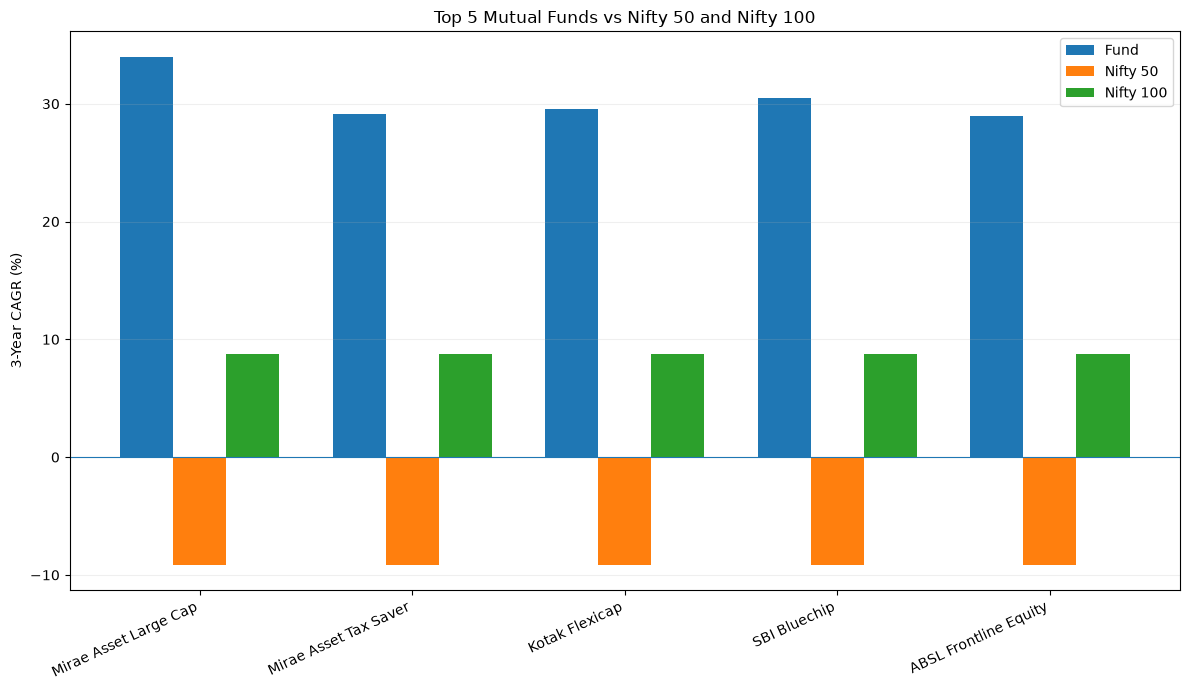


Chart saved to: c:\Users\Abhinandhan\mutual-fund-project\reports\performance_top5_vs_benchmarks.png


In [29]:
# ============================================================
# Step 126 — Top 5 Funds vs Nifty 50 & Nifty 100
# ============================================================

# Create comparison table
benchmark_comparison = tracking_df[
    ["scheme_name", "fund_cagr_3Y"]
].copy()

benchmark_comparison["NIFTY50"] = nifty50_cagr
benchmark_comparison["NIFTY100"] = benchmark_cagr[
    benchmark_cagr["benchmark"] == "NIFTY100"
]["cagr_3Y"].iloc[0]

print("3-Year CAGR comparison:")
print(
    benchmark_comparison.round(2).to_string(index=False)
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

comparison_plot = benchmark_comparison.copy()

# Shorter names for readability
comparison_plot["fund"] = comparison_plot["scheme_name"].str.replace(
    " Fund - Regular - Growth", "", regex=False
).str.replace(
    " Fund - Regular Plan - Growth", "", regex=False
).str.replace(
    " Fund - Direct - Growth", "", regex=False
)

x = np.arange(len(comparison_plot))
width = 0.25

plt.figure(figsize=(12, 7))

plt.bar(
    x - width,
    comparison_plot["fund_cagr_3Y"],
    width,
    label="Fund"
)

plt.bar(
    x,
    comparison_plot["NIFTY50"],
    width,
    label="Nifty 50"
)

plt.bar(
    x + width,
    comparison_plot["NIFTY100"],
    width,
    label="Nifty 100"
)

plt.axhline(0, linewidth=0.8)

plt.xticks(
    x,
    comparison_plot["fund"],
    rotation=25,
    ha="right"
)

plt.ylabel("3-Year CAGR (%)")
plt.title("Top 5 Mutual Funds vs Nifty 50 and Nifty 100")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()

chart_path = REPORTS_DIR / "performance_top5_vs_benchmarks.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nChart saved to:", chart_path)

In [30]:
# ============================================================
# Step 127 — Export Performance Scorecard
# ============================================================

scorecard_output = scorecard[
    [
        "rank",
        "amfi_code",
        "scheme_name",
        "cagr_3Y",
        "sharpe_ratio",
        "alpha_pct",
        "expense_ratio_pct",
        "max_drawdown_pct",
        "return_score",
        "sharpe_score",
        "alpha_score",
        "expense_score",
        "drawdown_score",
        "final_score"
    ]
].copy()

scorecard_output.to_csv(
    REPORTS_DIR / "performance_scorecard.csv",
    index=False
)

print("Performance scorecard exported successfully.")
print("Rows:", len(scorecard_output))
print(
    "File:",
    REPORTS_DIR / "performance_scorecard.csv"
)

print("\nTop 5:")
print(
    scorecard_output.head(5).round(2).to_string(index=False)
)

KeyError: "['alpha_pct', 'max_drawdown_pct'] not in index"

In [ ]:
print("Scorecard columns:")
print(scorecard.columns.tolist())

print("\nFirst 3 rows:")
print(scorecard.head(3).to_string(index=False))

Scorecard columns:
['amfi_code', 'scheme_name', 'cagr_3Y', 'sharpe_ratio', 'alpha', 'max_drawdown', 'expense_ratio_pct', 'return_score', 'sharpe_score', 'alpha_score', 'expense_score', 'drawdown_score', 'final_score', 'rank']

First 3 rows:
 amfi_code                                   scheme_name   cagr_3Y  sharpe_ratio    alpha  max_drawdown  expense_ratio_pct  return_score  sharpe_score  alpha_score  expense_score  drawdown_score  final_score  rank
    148567 Mirae Asset Large Cap Fund - Regular - Growth 33.991970      1.637441 0.269838     -0.112657               1.46          97.5         100.0         85.0          57.50            82.5      88.1250     1
    148569 Mirae Asset Tax Saver Fund - Regular - Growth 29.171358      1.367749 0.282704     -0.163967               1.60          82.5          95.0         92.5          91.25            50.0      85.6875     2
    120843        Kotak Flexicap Fund - Regular - Growth 29.575111      1.458908 0.273305     -0.129740              

In [ ]:
# ============================================================
# Step 127B — Export Performance Scorecard
# ============================================================

scorecard_output = scorecard[
    [
        "rank",
        "amfi_code",
        "scheme_name",
        "cagr_3Y",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown",
        "return_score",
        "sharpe_score",
        "alpha_score",
        "expense_score",
        "drawdown_score",
        "final_score"
    ]
].copy()

scorecard_output.to_csv(
    REPORTS_DIR / "performance_scorecard.csv",
    index=False
)

print("Performance scorecard exported successfully.")
print("Rows:", len(scorecard_output))
print("File:", REPORTS_DIR / "performance_scorecard.csv")

print("\nTop 5:")
print(
    scorecard_output.head(5).round(2).to_string(index=False)
)

Performance scorecard exported successfully.
Rows: 40
File: c:\Users\Abhinandhan\mutual-fund-project\reports\performance_scorecard.csv

Top 5:
 rank  amfi_code                                   scheme_name  cagr_3Y  sharpe_ratio  alpha  expense_ratio_pct  max_drawdown  return_score  sharpe_score  alpha_score  expense_score  drawdown_score  final_score
    1     148567 Mirae Asset Large Cap Fund - Regular - Growth    33.99          1.64   0.27               1.46         -0.11          97.5         100.0         85.0          57.50            82.5        88.12
    2     148569 Mirae Asset Tax Saver Fund - Regular - Growth    29.17          1.37   0.28               1.60         -0.16          82.5          95.0         92.5          91.25            50.0        85.69
    3     120843        Kotak Flexicap Fund - Regular - Growth    29.58          1.46   0.27               1.45         -0.13          85.0          97.5         90.0          55.00            70.0        83.12
    4     119